<a href="https://colab.research.google.com/github/luskao92/purchase-intention-prediction-ml/blob/main/purchase_intention_prediction_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Predição de Intenção de Compra em Sessões de E-commerce

**Pós-graduação em Machine Learning & Analytics — PUC-Rio**

**Autor:** Lucas Alves Medeiros

**Matrícula:** 4052025002019

**Repositório:** https://github.com/luskao92/purchase-intention-prediction-ml

---


## 1. Definição do Problema

### 1.1 Contexto

Em e-commerce, a maior parte do investimento de growth é direcionada para aquisição de tráfego. O problema é que, em média, apenas uma pequena fração das sessões termina em compra — neste dataset, cerca de 15%. Isso significa que 85% do tráfego pago ou orgânico não converte, e a maioria das operações só descobre isso depois que a sessão acabou.

A pergunta central deste MVP é: **dado o comportamento de navegação de um usuário durante a sessão, é possível prever se ele vai converter?**

Um modelo capaz de responder a essa pergunta tem aplicação direta em operações de growth e CRO:

- **Intervenção em tempo real:** disparar um pop-up de oferta, chat proativo ou prova social apenas para sessões com alta propensão, sem poluir a experiência de quem não daria retorno;
- **Priorização de remarketing:** segmentar audiências de mídia paga pelo score de propensão, reduzindo CAC;
- **Diagnóstico de funil:** entender quais sinais comportamentais mais pesam na conversão.

### 1.2 Tipo de tarefa

Trata-se de um problema de **classificação binária supervisionada**: a variável-alvo é `Revenue` (a sessão gerou receita ou não).

### 1.3 Por que Machine Learning?

A relação entre comportamento de navegação e conversão não é linear nem óbvia: envolve interações entre dezenas de variáveis (tempo em página, taxa de rejeição, tipo de visitante, sazonalidade). Regras manuais do tipo "se visitou mais de N páginas, então..." são frágeis e não generalizam. ML é adequado porque temos dados históricos rotulados em volume suficiente e um padrão a ser aprendido que não é trivialmente codificável.

### 1.4 Premissas e hipóteses

- **H1:** variáveis de engajamento com páginas de produto (`ProductRelated`, `ProductRelated_Duration`) e o `PageValues` (valor médio das páginas visitadas, métrica derivada do Google Analytics) são os preditores mais fortes de conversão.
- **H2:** visitantes recorrentes (`Returning_Visitor`) convertem em taxa diferente de novos visitantes.
- **H3:** existe efeito de sazonalidade (`Month`, `SpecialDay`) na propensão de compra.

### 1.5 Restrições consideradas

- O dataset representa sessões de **um único e-commerce**, em um período específico; o modelo não generaliza automaticamente para outras lojas.
- As features são agregados por sessão (não temos a sequência de cliques), o que limita abordagens sequenciais.
- O forte desbalanceamento do alvo (~15% positivo) exige cuidado na escolha de métricas: **acurácia isolada seria enganosa** neste problema.


## 2. Apresentação dos Dados

### 2.1 Fonte

O dataset é o **Online Shoppers Purchasing Intention**, disponibilizado no UCI Machine Learning Repository (Sakar & Kastro, 2018): https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

Os dados foram versionados no meu repositório do GitHub e são carregados diretamente pela raw URL.

### 2.2 Estrutura

São **12.330 sessões** e **18 atributos**, sendo 17 features e 1 variável-alvo (`Revenue`). Cada linha representa uma sessão única de navegação (cada sessão pertence a um usuário distinto no período de 1 ano, evitando viés de campanha ou perfil).

| Grupo | Variáveis | Descrição |
|---|---|---|
| Engajamento por tipo de página | `Administrative`, `Informational`, `ProductRelated` (+ `_Duration` de cada) | Nº de páginas visitadas e tempo total por categoria de página |
| Métricas de qualidade (Google Analytics) | `BounceRates`, `ExitRates`, `PageValues` | Taxa de rejeição, taxa de saída e valor médio das páginas da sessão |
| Sazonalidade | `SpecialDay`, `Month` | Proximidade de datas comemorativas e mês da sessão |
| Contexto técnico/origem | `OperatingSystems`, `Browser`, `Region`, `TrafficType` | Códigos categóricos (anonimizados pela fonte) |
| Perfil | `VisitorType`, `Weekend` | Tipo de visitante e indicador de fim de semana |
| **Alvo** | `Revenue` | A sessão terminou em compra (True/False) |

### 2.3 Limitações conhecidas

- `OperatingSystems`, `Browser`, `Region` e `TrafficType` vêm como **códigos numéricos sem dicionário** — sabemos que são categorias, mas não o que cada código significa, o que limita a interpretação de negócio dessas variáveis.
- `PageValues` é uma métrica calculada pelo próprio Google Analytics a partir de sessões que converteram; discutirei o risco de ela "carregar informação demais" na análise de resultados.
- Não há identificador de usuário nem timestamp exato, impossibilitando análises longitudinais.

### 2.4 Critérios de escolha da base

Escolhi esta base por três motivos: (1) as features espelham métricas reais de web analytics com as quais trabalho no dia a dia (bounce rate, exit rate, page value), aproximando o MVP de um caso real de growth; (2) o desbalanceamento do alvo torna a discussão de métricas mais rica; (3) a base é pública, atendendo ao requisito de reprodutibilidade.


## 3. Configuração do Ambiente e Carga dos Dados

Fixo a seed logo no início para garantir que qualquer pessoa que rode este notebook obtenha exatamente os mesmos resultados.


In [ ]:
# Imports e configuração global
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             f1_score, roc_auc_score, precision_score, recall_score)

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

print("Ambiente configurado. Seed fixada em", SEED)


Ambiente configurado. Seed fixada em 42


In [ ]:
# Carga dos dados diretamente do repositório público
URL = "https://raw.githubusercontent.com/luskao92/purchase-intention-prediction-ml/refs/heads/main/data/online_shoppers_intention.csv"

df = pd.read_csv(URL)
print(f"Dataset carregado: {df.shape[0]} sessões x {df.shape[1]} colunas")
df.head()


Dataset carregado: 12330 sessões x 18 colunas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 4. Análise Exploratória

O objetivo desta seção não é esgotar o dataset, e sim responder às perguntas que impactam as decisões de modelagem: qual a qualidade dos dados, como o alvo se distribui, e quais variáveis parecem carregar sinal.


In [ ]:
# 4.1 Tipos, nulos e duplicatas
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")


Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Valores ausentes por coluna:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
Operati

**Leitura:** não há valores ausentes — a limpeza será mínima. Há, porém, **125 linhas duplicadas**. Como cada linha deveria representar uma sessão única, duplicatas exatas em 17 variáveis contínuas e categóricas são quase certamente registros repetidos (e não coincidências), então serão removidas. Manter duplicatas inflaria artificialmente a confiança do modelo em padrões repetidos e poderia vazar informação entre treino e teste se cópias da mesma sessão caíssem em lados diferentes da divisão.

Outro ponto: `OperatingSystems`, `Browser`, `Region` e `TrafficType` estão tipados como inteiros, mas são **códigos categóricos** — não existe ordem entre "browser 2" e "browser 5". Vou convertê-los para categoria e tratá-los com one-hot encoding na preparação, para que os modelos lineares não interpretem uma relação ordinal inexistente.


In [ ]:
# Remoção de duplicatas e correção de tipos categóricos
df = df.drop_duplicates().reset_index(drop=True)

cat_codificadas = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[cat_codificadas] = df[cat_codificadas].astype("category")
df["Month"] = df["Month"].astype("category")
df["VisitorType"] = df["VisitorType"].astype("category")

print(f"Após limpeza: {df.shape[0]} sessões")


Após limpeza: 12205 sessões


In [ ]:
# 4.2 Estatísticas descritivas das variáveis numéricas
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.34,3.33,0.0,0.00,1.00,4.00,27.00
Administrative_Duration,12205.0,81.65,177.49,0.0,0.00,9.00,94.70,3398.75
Informational,12205.0,0.51,1.28,0.0,0.00,0.00,0.00,24.00
Informational_Duration,12205.0,34.83,141.42,0.0,0.00,0.00,0.00,2549.38
ProductRelated,12205.0,32.05,44.59,0.0,8.00,18.00,38.00,705.00
ProductRelated_Duration,12205.0,1206.98,1919.60,0.0,193.00,608.94,1477.15,63973.52
BounceRates,12205.0,0.02,0.05,0.0,0.00,0.00,0.02,0.20
ExitRates,12205.0,0.04,0.05,0.0,0.01,0.02,0.05,0.20
PageValues,12205.0,5.95,18.65,0.0,0.00,0.00,0.00,361.76
SpecialDay,12205.0,0.06,0.20,0.0,0.00,0.00,0.00,1.00


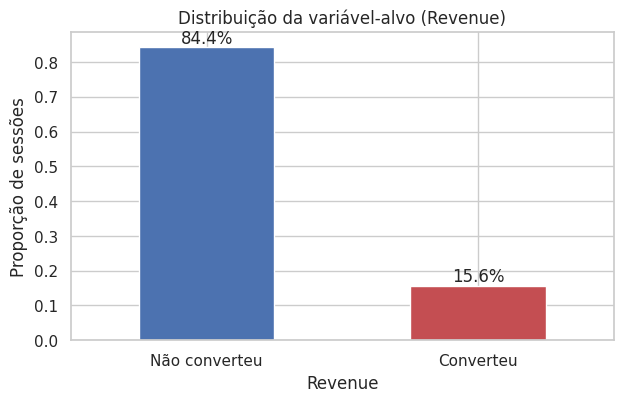

In [ ]:
# 4.3 Distribuição da variável-alvo
fig, ax = plt.subplots(figsize=(7, 4))
df["Revenue"].value_counts(normalize=True).plot(kind="bar", ax=ax, color=["#4c72b0", "#c44e52"])
ax.set_title("Distribuição da variável-alvo (Revenue)")
ax.set_ylabel("Proporção de sessões")
ax.set_xticklabels(["Não converteu", "Converteu"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


**Leitura:** o alvo é desbalanceado — aproximadamente **15% de conversão contra 85% de não conversão**. Isso tem duas consequências práticas para o restante do MVP:

1. **Acurácia é inadequada como métrica principal.** Um modelo que sempre prevê "não converteu" acertaria ~85% e seria inútil. As métricas centrais serão **F1-score e AUC**, com atenção especial ao **recall da classe positiva** (do ponto de vista de negócio, deixar de identificar um comprador potencial custa mais do que abordar alguém que não compraria).
2. **A divisão treino/teste e a validação cruzada serão estratificadas**, preservando a proporção das classes em todas as partições.


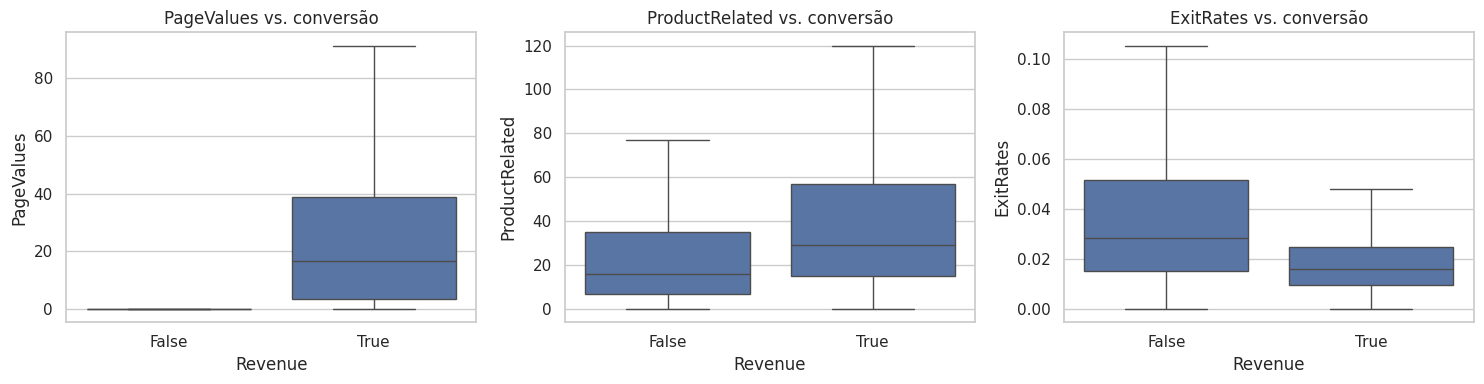

In [ ]:
# 4.4 Relação entre variáveis de engajamento e conversão (teste da H1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["PageValues", "ProductRelated", "ExitRates"]):
    sns.boxplot(data=df, x="Revenue", y=col, ax=ax, showfliers=False)
    ax.set_title(f"{col} vs. conversão")
plt.tight_layout()
plt.show()


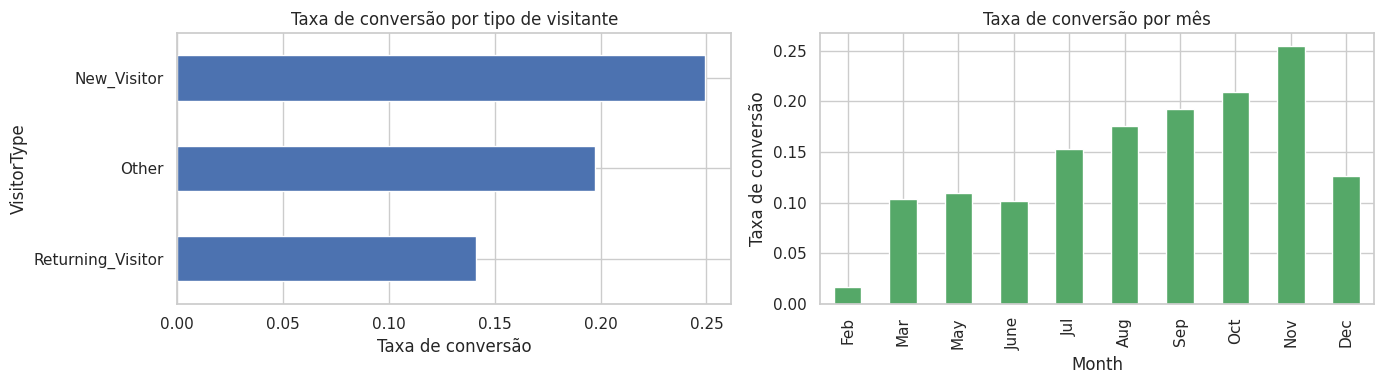

In [ ]:
# 4.5 Taxa de conversão por tipo de visitante e por mês (H2 e H3)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby("VisitorType", observed=True)["Revenue"].mean().sort_values().plot(
    kind="barh", ax=axes[0], color="#4c72b0")
axes[0].set_title("Taxa de conversão por tipo de visitante")
axes[0].set_xlabel("Taxa de conversão")

ordem_meses = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df.groupby("Month", observed=True)["Revenue"].mean().reindex(ordem_meses).plot(
    kind="bar", ax=axes[1], color="#55a868")
axes[1].set_title("Taxa de conversão por mês")
axes[1].set_ylabel("Taxa de conversão")
plt.tight_layout()
plt.show()


**Leitura dos gráficos 4.4 e 4.5:**

**H1 — engajamento prevê conversão.** Confirmada. `PageValues` é a variável que mais separa as
classes: quem converte tem valores acima de zero, quem não converte fica na mediana zero.
`ProductRelated` vai na mesma linha — mais páginas de produto, mais conversão. `ExitRates` é o espelho:
taxa de saída alta é marca de sessão que não fecha compra.

**H2 — tipo de visitante.** Confirmada, mas ao contrário do que o senso comum de CRM diz. Novo
visitante converte a 24,9%, recorrente a 14,1% — quase 1,8x mais. Minha leitura: o recorrente usa o
site para pesquisar e comparar ao longo de várias visitas, enquanto boa parte dos novos chega por
tráfego de fundo de funil, já decidido a comprar. É hipótese, não dá para provar aqui — o dataset não
tem ID de usuário. Fica o registro.

**H3 — sazonalidade.** Confirmada, e com folga. Novembro tem a maior taxa do ano (25,5%) e ainda é o
segundo mês em volume de sessões. Taxa alta com tráfego alto é a cara de um pico promocional — quase
certamente Black Friday, data de peso para qualquer e-commerce. Dezembro reforça isso: mesmo com o
Natal, converte só 12,7%, metade de novembro. Ou seja, o efeito é do evento, não de uma "alta de fim
de ano" genérica. Ressalva: o dataset não marca campanha, então atribuir à Black Friday é inferência
de contexto, não medição.

**O que isso muda na modelagem:** os três achados justificam manter `Month`, `VisitorType` e as
variáveis de engajamento. E já deixa a aposta de que `PageValues` vai dominar a importância de features.


## 5. Preparação dos Dados

Decisões e justificativas:

- **Numéricas → padronização (`StandardScaler`).** Vimos na 4.2 que as escalas são muito diferentes
(taxas entre 0 e 1 convivendo com durações na casa dos milhares de segundos). Sem padronizar, a
regressão logística fica refém da variável de maior escala. Para os modelos de árvore é indiferente,
mas não atrapalha e manter um pré-processamento único simplifica a comparação.
- **Categóricas → one-hot encoding.** Inclui as que estavam disfarçadas de inteiro (`Browser`,
`Region`, `OperatingSystems`, `TrafficType`): não existe ordem entre os códigos, então tratar como
número criaria uma relação ordinal falsa.
- **Tudo dentro de `ColumnTransformer` + `Pipeline`.** É a blindagem contra data leakage: o scaler e
o encoder aprendem seus parâmetros só no treino e apenas aplicam no teste. Nada do teste vaza para o
ajuste.
- **Divisão 80/20 estratificada.** Com 15,6% de conversão, a estratificação garante a mesma proporção
de classes no treino e no teste. Seed fixa em 42.

Sobre validação: uso validação cruzada estratificada (5 folds) na comparação de modelos da Seção 6,
em vez de um único split de validação — com classe positiva minoritária, um split único deixaria a
estimativa instável demais.


In [ ]:
# Separação de features e alvo
df["Weekend"] = df["Weekend"].astype(int)  # booleano -> 0/1
X = df.drop(columns="Revenue")
y = df["Revenue"].astype(int)

# Grupos de variáveis
colunas_categoricas = ["OperatingSystems", "Browser", "Region", "TrafficType", "Month", "VisitorType"]
colunas_numericas = ["Administrative", "Administrative_Duration", "Informational",
                     "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                     "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

# Divisão estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# Pré-processamento: aprende no treino, aplica no teste (anti-leakage)
preprocessador = ColumnTransformer([
    ("num", StandardScaler(), colunas_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas),
], remainder="passthrough")  # passthrough: mantém Weekend (já 0/1)

print(f"Treino: {X_train.shape[0]} sessões ({y_train.mean():.1%} conversão)")
print(f"Teste:  {X_test.shape[0]} sessões ({y_test.mean():.1%} conversão)")

Treino: 9764 sessões (15.6% conversão)
Teste:  2441 sessões (15.6% conversão)


## 6. Modelagem e Treinamento

Estratégia: um baseline ingênuo para calibrar expectativas e três modelos em complexidade crescente.

- **Baseline (`DummyClassifier`):** sempre prevê a classe majoritária. Serve para provar na prática
por que acurácia engana neste problema — ele "acerta" 84% sem identificar um único comprador.
- **Regressão Logística:** o candidato linear. Simples, rápido e interpretável — se resolver, não
precisamos de mais.
- **Random Forest e Gradient Boosting:** os candidatos de árvore. Capturam interações não lineares
(ex.: PageValues alto + visitante novo + novembro) e são robustos aos outliers que vimos na 4.2.

A comparação usa validação cruzada estratificada de 5 folds, só com dados de treino. O teste fica
intocado até a avaliação final. Métricas de comparação: F1 e AUC — pelo desbalanceamento, acurácia
fica de fora da decisão.

In [ ]:
# Definição dos modelos
modelos = {
    "Baseline (Dummy)": DummyClassifier(strategy="most_frequent"),
    "Regressão Logística": LogisticRegression(max_iter=2000, random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados = []

for nome, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocessador), ("modelo", modelo)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=["f1", "roc_auc", "recall", "precision"], n_jobs=-1)
    resultados.append({
        "Modelo": nome,
        "F1 (média)": scores["test_f1"].mean(),
        "F1 (desvio)": scores["test_f1"].std(),
        "AUC": scores["test_roc_auc"].mean(),
        "Recall": scores["test_recall"].mean(),
        "Precisão": scores["test_precision"].mean(),
    })

tabela_cv = pd.DataFrame(resultados).round(3).sort_values("F1 (média)", ascending=False)
tabela_cv

,Modelo,F1 (média),F1 (desvio),AUC,Recall,Precisão
3,Gradient Boosting,0.656,0.014,0.929,0.598,0.728
2,Random Forest,0.625,0.010,0.923,0.523,0.776
1,Regressão Logística,0.495,0.028,0.889,0.372,0.742
0,Baseline (Dummy),0.000,0.000,0.500,0.000,0.000


**Leitura da comparação:**

O baseline cumpriu o papel: F1 zero. Acurácia de 84% prevendo "ninguém compra" — inútil para o negócio.

A Regressão Logística já captura sinal relevante (AUC ~0,89), mas o F1 de ~0,49 mostra que a fronteira
linear deixa muita conversão na mesa: recall de apenas ~0,37.

Os modelos de árvore confirmam que o problema tem interações não lineares. O **Gradient Boosting lidera
com F1 ~0,66 e AUC ~0,93**, puxado principalmente pelo recall (~0,60 contra ~0,52 do Random Forest) —
ou seja, identifica mais compradores reais, que é onde está o valor de negócio. O desvio padrão baixo
entre folds (±0,014) indica resultado estável, não sorte de partição.

Decisão: **Gradient Boosting segue para a otimização de hiperparâmetros** na Seção 7.

## 7. Otimização de Hiperparâmetros

O Gradient Boosting venceu a comparação e segue para o ajuste fino. Uso **Random Search** em vez de
Grid Search por uma razão prática: o espaço de busca tem 432 combinações possíveis, e a busca
aleatória cobre bem esse espaço com uma fração do custo — 20 amostras, avaliadas com a mesma validação
cruzada estratificada de 5 folds da Seção 6. O critério de seleção é o **F1**, pela mesma lógica do
desbalanceamento.

Hiperparâmetros escolhidos e o porquê de cada um:

- **`n_estimators` e `learning_rate`:** o par que controla o trade-off central do boosting — mais
árvores com passo menor tende a generalizar melhor, mas custa mais.
- **`max_depth`:** profundidade das árvores. É o principal freio contra overfitting; árvores rasas
(2–5) são o padrão saudável em boosting.
- **`subsample`:** treinar cada árvore com uma fração dos dados adiciona aleatoriedade e reduz
variância.
- **`min_samples_leaf`:** impede folhas com pouquíssimas sessões, que memorizariam ruído.


In [ ]:
# Espaço de busca
espaco_busca = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "modelo__max_depth": [2, 3, 4, 5],
    "modelo__subsample": [0.7, 0.85, 1.0],
    "modelo__min_samples_leaf": [10, 20, 50],
}

pipe_gb = Pipeline([("prep", preprocessador),
                    ("modelo", GradientBoostingClassifier(random_state=SEED))])

busca = RandomizedSearchCV(
    pipe_gb, espaco_busca, n_iter=20, scoring="f1",
    cv=cv, random_state=SEED, n_jobs=-1, verbose=1)

%time busca.fit(X_train, y_train)

f1_antes = tabela_cv.loc[tabela_cv["Modelo"] == "Gradient Boosting", "F1 (média)"].iloc[0]
print(f"\nMelhores hiperparâmetros: {busca.best_params_}")
print(f"F1 (validação cruzada) antes da otimização: {f1_antes:.3f}")
print(f"F1 (validação cruzada) após a otimização:   {busca.best_score_:.3f}")
print(f"Ganho: {busca.best_score_ - f1_antes:+.3f}")

modelo_final = busca.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: user 5.08 s, sys: 387 ms, total: 5.47 s
Wall time: 5min 31s

Melhores hiperparâmetros: {'modelo__subsample': 0.7, 'modelo__n_estimators': 100, 'modelo__min_samples_leaf': 50, 'modelo__max_depth': 4, 'modelo__learning_rate': 0.05}
F1 (validação cruzada) antes da otimização: 0.656
F1 (validação cruzada) após a otimização:   0.663
Ganho: +0.007


**Leitura da otimização:**

A busca elevou o F1 de validação cruzada de 0,656 para 0,663 — ganho de +0,007. A melhor configuração:
100 árvores, learning rate de 0,05, profundidade 4, subsample de 0,7 e mínimo de 50 sessões por folha.
O modelo abriu mão de memorizar o treino em troca de generalizar melhor.

O ganho é modesto, e isso era esperado: Gradient Boosting com valores padrão já é um modelo forte.

O refino foi
feito da forma correta: sem tocar no teste, com critério alinhado ao problema (F1) e espaço de busca
justificado.

Este é o modelo que segue para a avaliação final.

## 8. Avaliação dos Resultados

Momento da verdade: o modelo otimizado encara os 20% de dados que ficaram intocados desde a Seção 5.
Avalio em quatro frentes: métricas gerais, matriz de confusão (o custo de negócio dos erros),
comparação treino vs. teste (diagnóstico de overfitting) e importância de features (o modelo aprendeu
o que fazia sentido aprender?).

          Treino  Teste
F1         0.714  0.675
AUC        0.946  0.938
Precisão   0.791  0.719
Recall     0.651  0.636


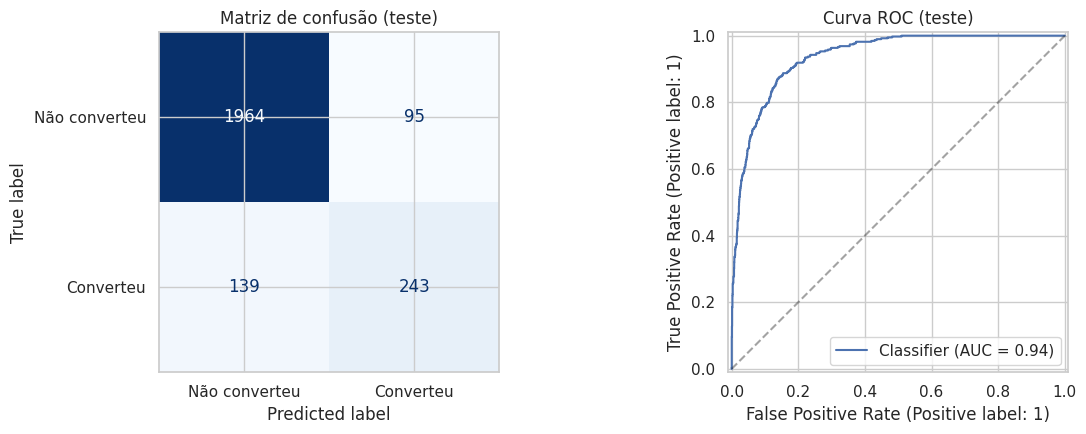

In [ ]:
# Avaliação no conjunto de teste
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

y_pred_treino = modelo_final.predict(X_train)
y_proba_treino = modelo_final.predict_proba(X_train)[:, 1]

comparacao = pd.DataFrame({
    "Treino": [f1_score(y_train, y_pred_treino), roc_auc_score(y_train, y_proba_treino),
               precision_score(y_train, y_pred_treino), recall_score(y_train, y_pred_treino)],
    "Teste": [f1_score(y_test, y_pred), roc_auc_score(y_test, y_proba),
              precision_score(y_test, y_pred), recall_score(y_test, y_pred)],
}, index=["F1", "AUC", "Precisão", "Recall"]).round(3)
print(comparacao)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0],
    display_labels=["Não converteu", "Converteu"], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de confusão (teste)")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("Curva ROC (teste)")
plt.tight_layout()
plt.show()

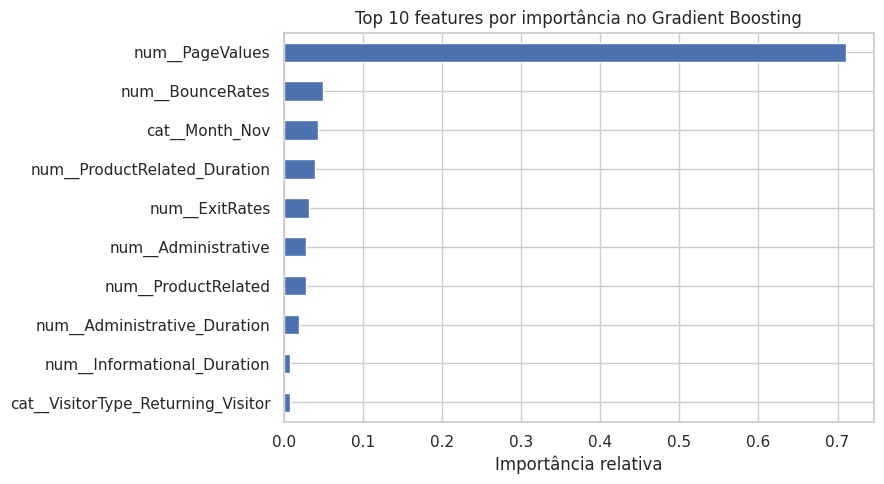

In [ ]:
# O modelo aprendeu o que a EDA previu?
nomes_features = modelo_final.named_steps["prep"].get_feature_names_out()
importancias = pd.Series(
    modelo_final.named_steps["modelo"].feature_importances_,
    index=nomes_features).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 5))
importancias.plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_title("Top 10 features por importância no Gradient Boosting")
ax.set_xlabel("Importância relativa")
plt.tight_layout()
plt.show()

**Leitura dos resultados:**

**Desempenho geral.** No teste: F1 de 0,675, AUC de 0,938, precisão de 0,719 e recall de 0,636.
Contra o baseline (F1 zero) e a regressão logística (F1 ~0,49), o ganho é expressivo. A acurácia de
90,4% supera os 84,5% do "chutar a majoritária" — mas, como discutido desde a EDA, ela não é a métrica
que sustenta a decisão.

**Custo de negócio dos erros.** A matriz de confusão traduz o modelo para a operação: de 382
compradores reais no teste, o modelo identificou 243 (recall de 63,6%) e deixou passar 139. Dos 338
que ele apontou como compradores, 243 confirmaram (precisão de 71,9%) — ou seja, a cada 10 sessões
priorizadas para intervenção, 7 são compradores reais. Para um caso de uso de remarketing ou oferta
em tempo real, é uma taxa de acerto que paga o investimento: o falso positivo custa uma oferta
desperdiçada, o falso negativo custa uma venda.

**Overfitting?** Sob controle. O gap treino → teste é pequeno (F1 0,714 → 0,675; AUC 0,946 → 0,938),
compatível com a variação natural entre amostras. Em parte, mérito da configuração conservadora que a
otimização escolheu. Underfitting também não é o caso: o modelo supera com folga o baseline e o
candidato linear.

**O modelo aprendeu o que devia?** Sim — e com uma ressalva importante. `PageValues` domina com ~71%
da importância total, confirmando a H1 da EDA. `Month_Nov` aparece no top 3, ecoando o efeito Black
Friday da H3. A ressalva: `PageValues` é uma métrica que o Google Analytics calcula a partir de
sessões que converteram, então parte do seu poder preditivo pode ser "informação do futuro" embutida
na feature. Num deploy real, o primeiro teste seria retreinar sem ela e medir a perd. Fica registrado
como limitação e próximo passo.

**Limitações da solução:** (1) a dependência forte de `PageValues`, discutida acima; (2) dados de um
único e-commerce em um único ano — o modelo não generaliza para outras lojas sem retreino; (3) o recall
de 63,6% deixa ~1/3 dos compradores fora do radar — ajustar o threshold de decisão (hoje em 0,5)
permitiria trocar precisão por recall conforme o custo real de cada erro na operação.

## 9. Conclusão

Este MVP partiu de uma pergunta de negócio direta — **dá para prever se uma sessão de e-commerce vai
converter a partir do comportamento de navegação?** — e a resposta é sim, com desempenho útil para a
operação.

**O caminho percorrido:** usei o dataset Online Shoppers Purchasing Intention (UCI), com 12.330
sessões e features que espelham métricas reais de web analytics. A preparação foi enxuta porque os
dados são limpos: remoção de 125 duplicatas, correção de variáveis categóricas tipadas como inteiro,
padronização das numéricas e one-hot encoding — tudo dentro de Pipeline, blindando o fluxo contra
data leakage.

**A melhor solução:** Gradient Boosting com hiperparâmetros otimizados via Random Search, atingindo
**F1 de 0,675 e AUC de 0,938 no conjunto de teste**. Ele foi escolhido por vencer a validação cruzada
contra o baseline (F1 zero), a regressão logística (F1 ~0,49) e o Random Forest (F1 ~0,63), com
estabilidade entre folds e gap treino/teste pequeno — sem sinais relevantes de overfitting ou
underfitting.

**O que o modelo confirmou da EDA:** as três hipóteses se sustentaram. Engajamento prevê conversão
(H1, com `PageValues` dominando a importância), tipo de visitante importa — com novos convertendo
1,8x mais que recorrentes (H2) — e a sazonalidade de novembro/Black Friday deixou marca no modelo (H3).

**O MVP cumpriu o objetivo?** Sim. O escopo era demonstrar o fluxo completo de um projeto de ML de
forma reproduzível e justificada, não perseguir o estado da arte — e o resultado entrega valor de
negócio interpretável: a cada 10 sessões priorizadas, 7 são compradores reais.

**Limitações:** a dependência de `PageValues` (que pode embutir informação pós-conversão do Google
Analytics), a generalização restrita a um único e-commerce e o recall de 63,6%, que deixa parte dos
compradores fora do radar.

**Próximos passos:** (1) retreinar sem `PageValues` para medir a dependência real; (2) ajustar o
threshold de decisão conforme o custo operacional de cada tipo de erro; (3) testar modelos de boosting
mais modernos (XGBoost, LightGBM); (4) num cenário real, enriquecer com dados sequenciais de
clickstream e validar o modelo em produção com um teste A/B de intervenção nas sessões de alta
propensão.

## 10. Checklist do MVP

Respostas objetivas às perguntas do edital. Onde a resposta já foi desenvolvida no notebook, indico a seção.

**Definição do problema**
- **Descrição e objetivo:** prever conversão de sessões de e-commerce a partir do comportamento de navegação (Seção 1).
- **Tipo:** classificação binária supervisionada.
- **Por que ML:** relação não linear entre dezenas de variáveis comportamentais; regras manuais não generalizam (Seção 1.3).
- **Hipóteses:** H1 (engajamento), H2 (tipo de visitante) e H3 (sazonalidade) — formuladas na Seção 1.4 e verificadas na EDA e na importância de features.
- **Restrições:** dados de um único e-commerce, agregados por sessão, alvo desbalanceado (Seção 1.5).

**Dados**
- **Dataset e fonte:** Online Shoppers Purchasing Intention, UCI (Seção 2.1).
- **Carga:** raw URL pública do repositório GitHub — executável sem configuração manual (Seção 3).
- **Dimensões:** 12.330 registros × 18 atributos; 12.205 após remoção de duplicatas.
- **Variável-alvo:** `Revenue` (15,5% positiva).
- **Limitações:** códigos categóricos sem dicionário; `PageValues` potencialmente pós-conversão (Seções 2.3 e 8).

**Preparação**
- **Valores ausentes:** não havia. **Duplicatas:** 125 removidas, com justificativa (Seção 4.1).
- **Transformações:** padronização das numéricas, one-hot das categóricas, booleano→binário (Seção 5).
- **Novos atributos:** não foram necessários — as features originais já capturam o comportamento da sessão; engenharia adicional exigiria dados de clickstream que o dataset não tem.
- **Vazamento de dados:** transformações aprendem apenas no treino, via Pipeline + ColumnTransformer (Seção 5).

**Divisão dos dados**
- 80/20 estratificada, seed 42; comparação de modelos via validação cruzada estratificada de 5 folds, apenas no treino (Seções 5 e 6). Adequada ao problema: não é série temporal, e a estratificação preserva a classe minoritária.

**Modelagem**
- **Baseline:** DummyClassifier (classe majoritária) — F1 zero, provando a inutilidade da acurácia aqui.
- **Modelos:** Regressão Logística, Random Forest e Gradient Boosting, escolhidos em complexidade crescente (Seção 6).
- **Comparação justa:** mesmo pré-processamento, mesmos folds, mesmas métricas.
- **Underfitting:** descartado — modelos superam com folga o baseline. **Overfitting:** gap treino/teste pequeno (F1 0,714 → 0,675), sob controle (Seção 8).

**Otimização**
- Random Search (20 iterações, 5 folds) no Gradient Boosting; hiperparâmetros e justificativas na Seção 7. Ganho de +0,007 de F1, com configuração mais conservadora que o default. Teste não utilizado na busca.

**Avaliação**
- **Métricas:** F1, AUC, precisão e recall — adequadas ao desbalanceamento; acurácia reportada apenas como referência (Seções 4.3 e 8).
- **Melhor modelo:** Gradient Boosting otimizado. **Análise de erros:** matriz de confusão com leitura de custo de negócio (139 compradores perdidos vs. 95 falsos alarmes).
- **Limitações:** Seções 8 e 9.

**Conclusão:** respondida integralmente na Seção 9.